In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sharpy.cases.templates.flying_wings as wings
import sharpy.sharpy_main
import json

In [3]:
u_inf = 25 # m/s
alpha_deg = 1
rho = 1.225

In [4]:
number_chordwise_panels = 4
number_spanwise_nodes = 16
wake_length_factor = 10

num_control_surfaces = 2

num_cores = 4
simulation_time =1.0

cases_folder = './cases/' # folder to store input files
output_folder = './output' # folder to save results
route_notebook_dir =  os.path.abspath('')

In [5]:
case_name = "myCaseControlTwo"

pazy_model_open_loop = wings.PazyControlSurface(M=number_chordwise_panels,
                                      N=number_spanwise_nodes,
                                      Mstar_fact=wake_length_factor,
                                      u_inf=u_inf,
                                      alpha=alpha_deg,
                                      cs_deflection=[0,0],
                                      n_control_surfaces=2,
                                      rho=rho,
                                      tip_rod = False,
                                      b_ref=2. * 1.2,
                                      main_chord= 0.2,
                                      pct_flap=0.2375, #285mm/1200mm
                                      aspect_ratio=(2. * 1.2) / 0.2,
                                      sweep=0,
                                      cs_type=0, #flap?
                                      n_surfaces=2,
                                      route=cases_folder + '/' + case_name,
                                      case_name=case_name,
                                      physical_time=simulation_time,)

def new_update_mass_stiff(self):
    import sharpy.utils.algebra as algebra

    #seeing our wing has roughly 2% of the area of the goland wing we have to scale the 
    #structural properties appropriately to achieve flutter, (as lift forces are proportional
    #to the wing area)
    width = 100E-3
    height = 2E-3
    E = 69e9  # Young's modulus in Pascals (Pa)
    G = 26e9  # Shear modulus in Pascals (Pa)
    rho = 2700

    # Cross-sectional properties
    A = width * height  # Area in m²
    Iy = (width * height**3) / 12  # Second moment of area about the y-axis (m⁴)
    Iz = (height * width**3) / 12  # Second moment of area about the z-axis (m⁴)
    print(Iy)
    print(Iz)
    J = 2*height**3*width/3  # Torsion constant approximation for rectangular section

    # Rigidity calculations
    EA = E * A
    GA = G * A
    GJ = G * J
    EIy = E * Iy
    EIz = E * Iz

    ea, ga = EA, GA
    gj = GJ
    eiy = EIy
    eiz = EIz
    base_stiffness = np.diag([ea, ga, ga, gj, eiy, eiz])
    self.stiffness = np.zeros((1, 6, 6))
    self.stiffness[0] = base_stiffness
    print(base_stiffness)
    
    m_unit = 1.42 
    j_tors = (Iy+Iz)*rho
    print(Iy+Iz)
    print(j_tors)
    pos_cg_b = np.array([0., self.c_ref * (self.main_cg - self.main_ea), 0.])
    m_chi_cg = algebra.skew(m_unit * pos_cg_b)
    self.mass = np.zeros((1, 6, 6))
    self.mass[0, :, :] = np.diag([m_unit, m_unit, m_unit,
                                    j_tors, .1 * j_tors, .9 * j_tors])

    self.mass[0, :3, 3:] = m_chi_cg
    self.mass[0, 3:, :3] = -m_chi_cg

    self.elem_stiffness = np.zeros((self.num_elem_tot,), dtype=int)
    self.elem_mass = np.zeros((self.num_elem_tot,), dtype=int)

    self.main_ea = 0.33
    self.main_cg = 0.43

pazy_model_open_loop.update_mass_stiff = new_update_mass_stiff.__get__(pazy_model_open_loop, wings.PazyControlSurface) 

In [6]:
def generate_aero_and_fem_input_files(model):
    model.clean_test_files()
    model.update_derived_params()
    model.generate_aero_file()
    model.generate_fem_file()
    
generate_aero_and_fem_input_files(pazy_model_open_loop)

print(pazy_model_open_loop.main_cg)

6.666666666666668e-11
1.666666666666667e-07
[[1.38000000e+07 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 5.20000000e+06 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 5.20000000e+06 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 1.38666667e+01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 4.60000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.15000000e+04]]
1.6673333333333336e-07
0.00045018000000000006
0.43


In [7]:
flow = ['BeamLoader',
        'AerogridLoader',
        'StaticCoupled',
        'AerogridPlot',
        'BeamPlot',
        'DynamicCoupled',
        ]
from get_settings_udp import get_settings_udp

pazy_model_open_loop.set_default_config_dict()
pazy_model_open_loop.config = get_settings_udp(pazy_model_open_loop,
                            flow,
                            num_cores=num_cores,
                            wake_length_factor=wake_length_factor,
                            output_folder = output_folder,
                            gust=False)
pazy_model_open_loop.config.write()

In [8]:
sharpy.sharpy_main.main(['', pazy_model_open_loop.route + pazy_model_open_loop.case_name + '.sharpy'])

--------------------------------------------------------------------------------
            ######  ##     ##    ###    ########  ########  ##    ##
           ##    ## ##     ##   ## ##   ##     ## ##     ##  ##  ##
           ##       ##     ##  ##   ##  ##     ## ##     ##   ####
            ######  ######### ##     ## ########  ########     ##
                 ## ##     ## ######### ##   ##   ##           ##
           ##    ## ##     ## ##     ## ##    ##  ##           ##
            ######  ##     ## ##     ## ##     ## ##           ##
--------------------------------------------------------------------------------
Aeroelastics Lab, Aeronautics Department.
    Copyright (c), Imperial College London.
    All rights reserved.
    License available at https://github.com/imperialcollegelondon/sharpy
Running SHARPy from /home/user/sharpy/sharpy
SHARPy being run is in /home/user/.local/lib/python3.10/site-packages
SHARPy output folder set
	./output//myCaseControlTwo/
Generating an ins

fatal: not a git repository (or any of the parent directories): .git


|  0  |  1  |  0.00000   | -0.0981  |  0.0000  |  6.8765  | -0.0000  |  0.1100  | -0.0000  |
|  1  |  1  |  -4.06309  | -0.1045  |  0.0000  |  7.0956  | -0.0001  |  0.1130  | -0.0000  |
|  2  |  1  |  -4.79995  | -0.1056  |  0.0000  |  7.1345  | -0.0001  |  0.1135  | -0.0000  |
|  3  |  1  |  -5.76026  | -0.1057  |  0.0000  |  7.1387  | -0.0001  |  0.1136  | -0.0000  |
|  0  |  2  |  0.00000   | -0.1503  |  0.0001  | 10.5845  | -0.0001  |  0.1644  | -0.0000  |
|  1  |  2  |  -3.75535  | -0.1585  |  0.0003  | 10.8582  | -0.0004  |  0.1676  | -0.0000  |
|  2  |  2  |  -4.46995  | -0.1600  |  0.0003  | 10.9092  | -0.0005  |  0.1682  | -0.0000  |
|  3  |  2  |  -5.38211  | -0.1602  |  0.0003  | 10.9153  | -0.0005  |  0.1682  | -0.0000  |
|  0  |  3  |  0.00000   | -0.2024  |  0.0006  | 14.2965  | -0.0007  |  0.2148  | -0.0000  |
|  1  |  3  |  -3.58824  | -0.2110  |  0.0013  | 14.5717  | -0.0014  |  0.2173  | -0.0001  |
|  2  |  3  |  -4.32399  | -0.2125  |  0.0015  | 14.6206  | -0.0016  |

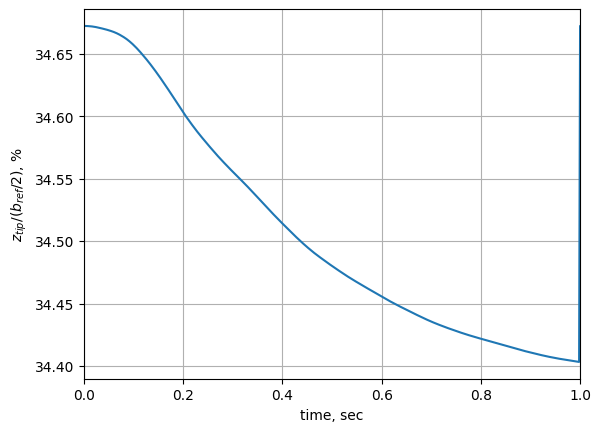

In [9]:
def get_resulting_vertical_tip_displacement(output_folder, model):    
    file_results = os.path.join(output_folder, 
                                 model.case_name, 
                                 'WriteVariablesTime',
                                 'struct_pos_node{}.dat'.format(model.num_node_surf))
    vertical_tip_displacement = np.loadtxt(file_results)[:,-1]
    
                                             
    return vertical_tip_displacement


tip_displacement_open_loop = get_resulting_vertical_tip_displacement(output_folder, 
                                                                     pazy_model_open_loop)


time_array = np.arange(0, len(tip_displacement_open_loop) * pazy_model_open_loop.dt, pazy_model_open_loop.dt)
normalised_tip_displacement = tip_displacement_open_loop/ (0.5*pazy_model_open_loop.b_ref) #normalise by half wing span
normalised_tip_displacement *=100# cconvert to percentnvert to percent
plt.plot(time_array, normalised_tip_displacement)
plt.xlabel('time, sec')
plt.ylabel('$z_{tip}/(b_{ref}/2)$, %')
plt.xlim([0., simulation_time])
plt.grid()
plt.show()

In [10]:
case_name = 'control2_ROM'

flow = ['BeamLoader',
        'AerogridLoader',
        'StaticCoupled',
        'DynamicCoupled',
        'Modal',
        'LinearAssembler',
        'SaveData',
        ]

simulation_time_ROM = pazy_model_open_loop.dt # only one timestep has to be performed
gust = False

In [11]:
use_rom = True
rom_settings = {
    'use': use_rom,
    'rom_method': 'Krylov',
    'rom_method_settings': {'Krylov': {
                                        'algorithm': 'mimo_rational_arnoldi',
                                        'r': 4,
                                        'frequency': np.array([0]),
                                        'single_side': 'observability',
                                        },
                           }
                }

In [12]:
num_modes = 20

In [13]:
unsteady_force_contribution = False
remove_gust_input_in_statespace = False

In [14]:
pazy_model_ROM = wings.PazyControlSurface(M=number_chordwise_panels,
                                      N=number_spanwise_nodes,
                                      Mstar_fact=wake_length_factor,
                                      u_inf=u_inf,
                                      alpha=alpha_deg,
                                      cs_deflection=[0,0],
                                      n_control_surfaces=2,
                                      rho=rho,
                                      tip_rod = False,
                                      b_ref=2. * 1.2,
                                      main_chord= 0.2,
                                      pct_flap=0.2375, #285mm/1200mm
                                      aspect_ratio=(2. * 1.2) / 0.2,
                                      sweep=0,
                                      cs_type=0, #flap?
                                      n_surfaces=2,
                                      route=cases_folder + '/' + case_name,
                                      case_name=case_name,
                                      physical_time=simulation_time,)

def new_update_mass_stiff(self):
    import sharpy.utils.algebra as algebra

    #seeing our wing has roughly 2% of the area of the goland wing we have to scale the 
    #structural properties appropriately to achieve flutter, (as lift forces are proportional
    #to the wing area)
    width = 100E-3
    height = 2E-3
    E = 69e9  # Young's modulus in Pascals (Pa)
    G = 26e9  # Shear modulus in Pascals (Pa)
    rho = 2700

    # Cross-sectional properties
    A = width * height  # Area in m²
    Iy = (width * height**3) / 12  # Second moment of area about the y-axis (m⁴)
    Iz = (height * width**3) / 12  # Second moment of area about the z-axis (m⁴)
    print(Iy)
    print(Iz)
    J = 2*height**3*width/3  # Torsion constant approximation for rectangular section

    # Rigidity calculations
    EA = E * A
    GA = G * A
    GJ = G * J
    EIy = E * Iy
    EIz = E * Iz

    ea, ga = EA, GA
    gj = GJ
    eiy = EIy
    eiz = EIz
    base_stiffness = np.diag([ea, ga, ga, gj, eiy, eiz])
    self.stiffness = np.zeros((1, 6, 6))
    self.stiffness[0] = base_stiffness
    print(base_stiffness)
    
    m_unit = 1.42 
    j_tors = (Iy+Iz)*rho
    print(Iy+Iz)
    print(j_tors)
    pos_cg_b = np.array([0., self.c_ref * (self.main_cg - self.main_ea), 0.])
    m_chi_cg = algebra.skew(m_unit * pos_cg_b)
    self.mass = np.zeros((1, 6, 6))
    self.mass[0, :, :] = np.diag([m_unit, m_unit, m_unit,
                                    j_tors, .1 * j_tors, .9 * j_tors])

    self.mass[0, :3, 3:] = m_chi_cg
    self.mass[0, 3:, :3] = -m_chi_cg

    self.elem_stiffness = np.zeros((self.num_elem_tot,), dtype=int)
    self.elem_mass = np.zeros((self.num_elem_tot,), dtype=int)

    self.main_ea = 0.33
    self.main_cg = 0.43

pazy_model_ROM.update_mass_stiff = new_update_mass_stiff.__get__(pazy_model_ROM, wings.PazyControlSurface) 

generate_aero_and_fem_input_files(pazy_model_ROM)

6.666666666666668e-11
1.666666666666667e-07
[[1.38000000e+07 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 5.20000000e+06 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 5.20000000e+06 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 1.38666667e+01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 4.60000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.15000000e+04]]
1.6673333333333336e-07
0.00045018000000000006


In [15]:
pazy_model_ROM.set_default_config_dict()
pazy_model_ROM.config = get_settings_udp(pazy_model_ROM,
                            flow,
                            num_cores=num_cores,
                            wake_length_factor=wake_length_factor,
                            output_folder = output_folder,
                            gust=gust,
                            num_modes = num_modes,
                            rom_settings = rom_settings,
                            remove_gust_input_in_statespace=remove_gust_input_in_statespace,
                            unsteady_force_distribution=unsteady_force_contribution)
pazy_model_ROM.config.write()

In [16]:
sharpy.sharpy_main.main(['', pazy_model_ROM.route + pazy_model_ROM.case_name + '.sharpy'])


--------------------------------------------------------------------------------
            ######  ##     ##    ###    ########  ########  ##    ##
           ##    ## ##     ##   ## ##   ##     ## ##     ##  ##  ##
           ##       ##     ##  ##   ##  ##     ## ##     ##   ####
            ######  ######### ##     ## ########  ########     ##
                 ## ##     ## ######### ##   ##   ##           ##
           ##    ## ##     ## ##     ## ##    ##  ##           ##
            ######  ##     ## ##     ## ##     ## ##           ##
--------------------------------------------------------------------------------
Aeroelastics Lab, Aeronautics Department.
    Copyright (c), Imperial College London.
    All rights reserved.
    License available at https://github.com/imperialcollegelondon/sharpy
Running SHARPy from /home/user/sharpy/sharpy
SHARPy being run is in /home/user/.local/lib/python3.10/site-packages
SHARPy output folder set
	./output//control2_ROM/
Generating an instanc

fatal: not a git repository (or any of the parent directories): .git


|  0  |  1  |  0.00000   | -0.0981  |  0.0000  |  6.8765  | -0.0000  |  0.1100  | -0.0000  |
|  1  |  1  |  -4.06309  | -0.1045  |  0.0000  |  7.0956  | -0.0001  |  0.1130  | -0.0000  |
|  2  |  1  |  -4.79995  | -0.1056  |  0.0000  |  7.1345  | -0.0001  |  0.1135  | -0.0000  |
|  3  |  1  |  -5.76026  | -0.1057  |  0.0000  |  7.1387  | -0.0001  |  0.1136  | -0.0000  |
|  0  |  2  |  0.00000   | -0.1503  |  0.0001  | 10.5845  | -0.0001  |  0.1644  | -0.0000  |
|  1  |  2  |  -3.75535  | -0.1585  |  0.0003  | 10.8582  | -0.0004  |  0.1676  | -0.0000  |
|  2  |  2  |  -4.46995  | -0.1600  |  0.0003  | 10.9092  | -0.0005  |  0.1682  | -0.0000  |
|  3  |  2  |  -5.38211  | -0.1602  |  0.0003  | 10.9153  | -0.0005  |  0.1682  | -0.0000  |
|  0  |  3  |  0.00000   | -0.2024  |  0.0006  | 14.2965  | -0.0007  |  0.2148  | -0.0000  |
|  1  |  3  |  -3.58824  | -0.2110  |  0.0013  | 14.5717  | -0.0014  |  0.2173  | -0.0001  |
|  2  |  3  |  -4.32399  | -0.2125  |  0.0015  | 14.6206  | -0.0016  |

/home/user/.local/lib/python3.10/site-packages/sharpy/linear/src/lingebm.py:313: UserWarning: Euler parametrisation not implemented - Either rigid body modes are not being used or this method has already been called.
  warnings.warn('Euler parametrisation not implemented - Either rigid body modes are not being used or this '



Linearising gravity terms...
	M = 0.00 kg
	X_CG A -> -1.22 0.77 0.00
Node  1 	-> B -0.000 -0.000 -0.000
			-> A 0.000 0.149 0.012
			-> G 0.001 0.149 0.012
	Node mass:
		Matrix: 0.2272
Node  2 	-> B -0.000 -0.000 -0.000
			-> A 0.000 0.296 0.045
			-> G 0.001 0.296 0.045
	Node mass:
		Matrix: 0.1136
Node  3 	-> B -0.000 -0.000 -0.000
			-> A 0.001 0.438 0.092
			-> G 0.002 0.438 0.092
	Node mass:
		Matrix: 0.2272
Node  4 	-> B -0.000 -0.000 -0.000
			-> A 0.001 0.577 0.149
			-> G 0.003 0.577 0.149
	Node mass:
		Matrix: 0.1136
Node  5 	-> B -0.000 -0.000 -0.000
			-> A 0.001 0.713 0.211
			-> G 0.005 0.713 0.211
	Node mass:
		Matrix: 0.2272
Node  6 	-> B -0.000 -0.000 -0.000
			-> A 0.001 0.848 0.277
			-> G 0.006 0.848 0.277
	Node mass:
		Matrix: 0.1136
Node  7 	-> B -0.000 -0.000 -0.000
			-> A 0.001 0.982 0.345
			-> G 0.007 0.982 0.345
	Node mass:
		Matrix: 0.2272
Node  8 	-> B -0.000 -0.000 -0.000
			-> A 0.001 1.116 0.412
			-> G 0.008 1.116 0.412
	Node mass:
		Matrix: 0.0568
No

In [17]:
folder_linear_results =os.path.join(output_folder, pazy_model_ROM.case_name,'linear_results')
if not os.path.exists(folder_linear_results):
    os.makedirs(folder_linear_results)

import scipy.io

parameter_matlab = {'num_aero_states': 80, # see log file
                    'num_modes': 20,  # see log file
                     'u_inf': float(pazy_model_ROM.u_inf),
                    'simulation_time': simulation_time,
                    'num_control_surfaces': num_control_surfaces,
                    'n_nodes': number_spanwise_nodes,
                    'control_input_start': 193 + 1, # see log file and + 1 for matlab indices
                    'gust_input_start': 192 + 1 , # see log file and + 1 for matlab indices
                   }

scipy.io.savemat(os.path.join(folder_linear_results, 'simulation_parameters.mat'), parameter_matlab)

In [23]:
import matlab.engine
eng = matlab.engine.start_matlab()
eng.control_design_script(route_notebook_dir)

ss requires one of the following:
  Control System Toolbox
  DSP System Toolbox
  Model Predictive Control Toolbox
  Signal Processing Toolbox

Error in read_SHARPy_state_space_system (line 32)
state_space_system = ss(A, B, C, D, dt);
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Error in control_design_script (line 11)
    [state_space_system, eta_ref] = read_SHARPy_state_space_system(...
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^



MatlabExecutionError: 
  File /home/user/sharpy/sharpy/matlab_functions/read_SHARPy_state_space_system.m, line 32, in read_SHARPy_state_space_system

  File /home/user/sharpy/sharpy/control_design_script.m, line 11, in control_design_script
Undefined function 'ss' for input arguments of type 'double'.


In [ ]:
# Clean Up Simulink Files
import shutil
folder_path = os.path.join(route_notebook_dir, 'slprj')
if os.path.exists(folder_path):
    shutil.rmtree(folder_path)

file_path = os.path.join(route_notebook_dir,  'PID_linear_model.slxc')
if os.path.exists(file_path):
    os.remove(file_path)